In [ ]:
# =============================================================================
# Section 5.3 -- CES Employment Data (Table 1), Setup
# =============================================================================
# Real-data experiment: assess reliability of three BLS CES (Current Employment
# Statistics) employment vintages against external Treasury withholding tax data.
#
# Notation:
#   x^ = reported employment level (vintage 1/2/3: first release, 1-month rev., final)
#   y  = withheld income & employment tax deposits (Treasury DTS) -- the signal
#   P  = unknown experiment matrix linking true employment to tax deposits
#
# Three vintages (paper Table 1):
#   X1_first   -- first release
#   X2_after1m -- one-month revision
#   X3_final   -- final (benchmark) estimate
#
# External signal Y1: Treasury Withheld Income and Employment Taxes (DTS),
#   monthly totals -- a proxy for true payroll activity (independent of BLS).
# =============================================================================
import pandas as pd
from calendar import month_abbr

# ==========
# File paths
# ==========
DTS_PATH = '../data/DTS_FedTaxDpst_20051003_20230213.csv'
TRI_TOTAL_NSA_PATH = '../data/tri_000000_NSA.csv'   # Total Nonfarm, NSA (vintage)

# ==========
# Helpers for vintage tables
# ==========
_abbr_to_num = {m: i for i, m in enumerate(month_abbr) if m}

def refcol_to_timestamp(col: str):
    """Convert vintage column name like 'Jan_39' -> Timestamp."""
    try:
        m_abbr, yy = col.split('_')
        mm = _abbr_to_num[m_abbr]
        yy = int(yy)
        yr = 1900 + yy if yy >= 39 else 2000 + yy
        return pd.Timestamp(year=yr, month=mm, day=1)
    except:
        return None

def build_vintage_X123(vintage_df: pd.DataFrame):
    """Build X1 (first), X2 (after 1 month), X3 (final) from vintage table."""
    ref_cols = [c for c in vintage_df.columns if c.lower() not in ('year','month')]
    records = []
    for c in ref_cols:
        ts = refcol_to_timestamp(c)
        if ts is None:
            continue
        s = pd.to_numeric(vintage_df[c], errors='coerce').dropna().reset_index(drop=True)
        if len(s) == 0:
            continue
        X1 = s.iloc[0]
        X3 = s.iloc[-1]
        X2 = s.iloc[1] if len(s) > 1 else X3
        records.append((ts, X1, X2, X3))
    return (pd.DataFrame(records, columns=['month','X1_first','X2_after1m','X3_final'])
              .sort_values('month').reset_index(drop=True))

# ==========
# 1) Build Y1 (Treasury: Withheld Income and Employment Taxes)
# ==========
dts = pd.read_csv(DTS_PATH, parse_dates=['Record Date'])
dts_filt = dts[dts['Federal Tax Deposit Type'] == 'Withheld Income and Employment Taxes'].copy()
dts_filt['month'] = dts_filt['Record Date'].dt.to_period('M').dt.to_timestamp()
Y1 = (dts_filt.groupby('month')['Federal Tax Deposits Today']
      .sum().reset_index().rename(columns={'Federal Tax Deposits Today': 'Y1'}))

# ==========
# 2) Build X1, X2, X3 (from vintage Total Nonfarm NSA)
# ==========
tri_total_nsa = pd.read_csv(TRI_TOTAL_NSA_PATH, low_memory=False)
X_df = build_vintage_X123(tri_total_nsa)

# ==========
# 3) Merge X and Y1
# ==========
merged_XY1 = X_df.merge(Y1, on='month', how='outer').sort_values('month').reset_index(drop=True)

print(merged_XY1.head(10))
print(merged_XY1.tail(10))
print("Non-null counts:\n", merged_XY1[['X1_first','X2_after1m','X3_final','Y1']].notna().sum())

# merged_XY1.to_csv('../data/merged_X123_Y1.csv', index=False)


       month  X1_first  X2_after1m  X3_final  Y1
0 1939-01-01   29296.0     29296.0   29296.0 NaN
1 1939-02-01   29394.0     29394.0   29394.0 NaN
2 1939-03-01   29804.0     29804.0   29804.0 NaN
3 1939-04-01   29786.0     29786.0   29786.0 NaN
4 1939-05-01   30145.0     30145.0   30145.0 NaN
5 1939-06-01   30520.0     30520.0   30520.0 NaN
6 1939-07-01   30472.0     30472.0   30472.0 NaN
7 1939-08-01   30870.0     30870.0   30870.0 NaN
8 1939-09-01   31608.0     31608.0   31608.0 NaN
9 1939-10-01   31975.0     31975.0   31975.0 NaN
          month  X1_first  X2_after1m  X3_final  Y1
1023 2024-04-01  158016.0    158001.0  157438.0 NaN
1024 2024-05-01  158918.0    158845.0  158256.0 NaN
1025 2024-06-01  159392.0    159360.0  158722.0 NaN
1026 2024-07-01  158445.0    158387.0  157771.0 NaN
1027 2024-08-01  158650.0    158717.0  158070.0 NaN
1028 2024-09-01  159177.0    159181.0  158527.0 NaN
1029 2024-10-01  160007.0    160035.0  159352.0 NaN
1030 2024-11-01  160560.0    160539.0  159882

X1_first: 3504384.0000000224
X2_after1m: 24920063.99999998
X3_final: 33918976.00000002


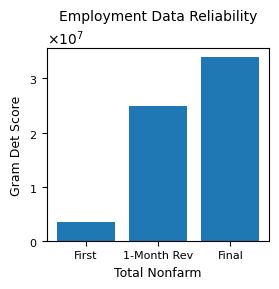

In [ ]:
# =============================================================================
# Section 5.3 -- Gram Determinant Score for CES Vintages (Table 1)
# =============================================================================
# Computes the plug-in Gram determinant score (Definition 4.5) for each of the
# three employment vintages using month-over-month increments.
#
# Score procedure:
#   1. Difference both x^ and y columns to get monthly changes.
#   2. Discretize each column into d=4 equal-frequency (quantile) buckets.
#   3. Build empirical joint table C[x^_bucket, y_bucket].
#   4. Score = det(C)^2.
#
# Expected ordering (Table 1): Final > 1-Month Rev > First release,
#   because more-revised estimates have higher informational content about y.
# Reported scores (paper Table 1): 3.504e6, 24.920e6, 33.919e6.
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Compute month-over-month increments (diff) for employment and tax series
inc_df = merged_XY1.copy()
for col in ['X1_first', 'X2_after1m', 'X3_final', 'Y1']:
    if col in inc_df:
        inc_df[col] = inc_df[col].diff()  # month-over-month change

# Drop rows with NaNs in any required column
inc_df = inc_df.dropna(subset=['X1_first', 'X2_after1m', 'X3_final', 'Y1']).reset_index(drop=True)

# Definition 4.5 (plug-in score) with delta kernel:
#   Discretize x^ and y into quantile buckets -> compute det(C)^2
def gram_det_score(df, x_col, y_col, buckets=4):
# def gram_det_score(df, x_col, y_col, buckets=3):
    t = df[[x_col, y_col]].dropna().copy()
    # Discretize into equal-frequency buckets (labels 1..buckets)
    t['X_bucket'] = pd.qcut(t[x_col], q=buckets, labels=False) + 1
    t['Y_bucket'] = pd.qcut(t[y_col], q=buckets, labels=False) + 1
    # Empirical joint table C[x^_bucket, y_bucket]
    M = pd.crosstab(t['X_bucket'], t['Y_bucket']).reindex(
        index=range(1, buckets+1),
        columns=range(1, buckets+1),
        fill_value=0
    )
    return float(np.linalg.det(M.values) ** 2)  # Gamma = det(C)^2

# Compute score for each vintage against Treasury withheld taxes (Y1)
ycol = 'Y1'  # Withheld Income & Employment Taxes (monthly change)
xcols = [c for c in ['X1_first', 'X2_after1m', 'X3_final'] if c in inc_df.columns]

scores = {x: gram_det_score(inc_df, x, ycol, buckets=4) for x in xcols}

# Human-friendly short labels
x_labels = {
    'X1_first':   'First',
    'X2_after1m': '1-Month Rev',
    'X3_final':   'Final'
}

plot_df = pd.DataFrame({
    'X_pretty': [x_labels['X1_first'], x_labels['X2_after1m'], x_labels['X3_final']],
    'Score': [scores['X1_first'], scores['X2_after1m'], scores['X3_final']]
})

for k in ['X1_first', 'X2_after1m', 'X3_final']:
    print(f"{k}: {scores.get(k)}")

plt.figure(figsize=(3, 3))
plt.bar(plot_df['X_pretty'], plot_df['Score'])
plt.title("Employment Data Reliability", fontsize=10)
plt.xlabel("Total Nonfarm", fontsize=9)
plt.ylabel("Gram Det Score", fontsize=9)
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=8)

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.tight_layout()
plt.show()
